# Task 1: Identifying the Prediction Target

The target variable for the assignment is "y"

The goal of the bank is to determine if a client will subscribe to a term deposit. The variable "y" is a binary variable which indicates if a client has subscribed to a term deposit or not. This variable is describing the outcome of the campaign, whereas the others are either attributes of clients or campaign information.

One variable that could superficially appear to be a target is "duration", the duration of the last contact with the customer. The duration is not known before the call is performed and is highly impactful on the final outcome. Finally after the call the outcome is known, they either agreed to subscribe or they didn't.

Another variable that could appear to be a target is "poutcome", the outcome of the previous marketing campaign not the current one. Superficially it may seem like the target variable.

# Task 2: Data Loading and Exploration


## Loading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df = pd.read_csv("bank-additional.csv", sep=';')
print(f"\nColumn names:\n{df.columns.tolist()}")
df.head()



Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## Structure of dataset

In [3]:
#See data types
#There are no explicit NaN values.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

Number of Observations: 4119
Number of features: 20 ("y" is the target and doesn't count as a feature)

Data types: 
- Numerical: "age", "duration", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "euribor3m", "nr.employed"
- Categorical: "job", "marital", "education", "default", "housing", "loan, "contact", "month", "day_of_week", "poutcome"
- Target (but also categorical): "y"

In [4]:
#Summary statistics for numerical variables
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
#See value counts for target variable
df['y'].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [6]:
#See relative frequencies for target variable
df['y'].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Target variable distribution
The target "y"  is very imbalanced.
No: 3668 - 89.1%
Yes: 451 - 10.9%

This could lead to potential problems as a model could achieve high accuracy by just predicting "no". We will have to value other measurements when making and training the model.

In [7]:
df['default'].value_counts(normalize=True)

default
no         0.804807
unknown    0.194950
yes        0.000243
Name: proportion, dtype: float64

## Explicit and Implicit missing values

In [8]:
implicit_unknown_counts = (df == 'unknown').sum()
implicit_999_counts = (df == 999).sum()

print("\n'Unknown' values per column:\n", implicit_unknown_counts[implicit_unknown_counts > 0])

print("\n'999' values per column:\n", implicit_999_counts[implicit_999_counts > 0])


'Unknown' values per column:
 job           39
marital       11
education    167
default      803
housing      105
loan         105
dtype: int64

'999' values per column:
 duration       1
pdays       3959
dtype: int64


### Implicit missing values summary

There are no explicit missing values, however there are many implicit missing values

**Treat as missing**
- "Unknown": job (39), marital (11), education (167), default (803), housing (105), loan (105)
- "999": pdays (3959)

**Ignored**
- "999" in duration (1)

The value in duration refers to the amount of seconds, not an unknown value so we must ignore/discard this result from the missing values

## Visualization of Distributions

Visualization of distributions:

Numerical: "Duration" and "age"

Categorical: "has_previous" and "job"

Although "previous" is a numerical value i have converted it into a categorical value to see if having been contacted before (y or n) has an effect on potential clients.

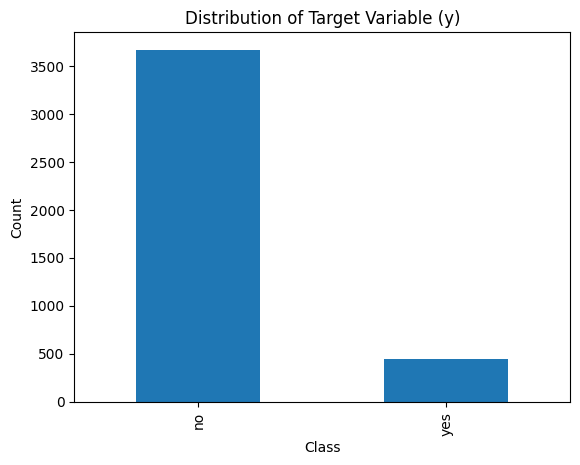

In [9]:
#Visualize distribution of target variable
df['y'].value_counts().plot(kind='bar')
plt.title("Distribution of Target Variable (y)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Numerical Variable Distributions

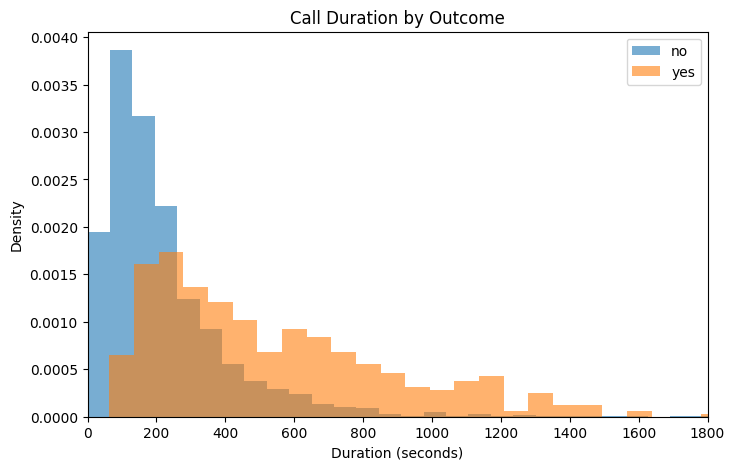

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df[df["y"] == "no"]["duration"],
         bins=50, alpha=0.6, label="no", density=True)

plt.hist(df[df["y"] == "yes"]["duration"],
         bins=50, alpha=0.6, label="yes", density=True)

plt.title("Call Duration by Outcome")
plt.xlabel("Duration (seconds)")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, 1800)

plt.show()

Histogram comparing call duration for customers who subscribed vs. those who did not

Longer call durations are often associated with successful subscriptions, so we can expect to see a right-skewed distribution for the "yes" class and a more left-skewed distribution for the "no" class.

This feature shouldn't be included as the outcome is known after the call ends therefore including it in the model would cause data leakage.


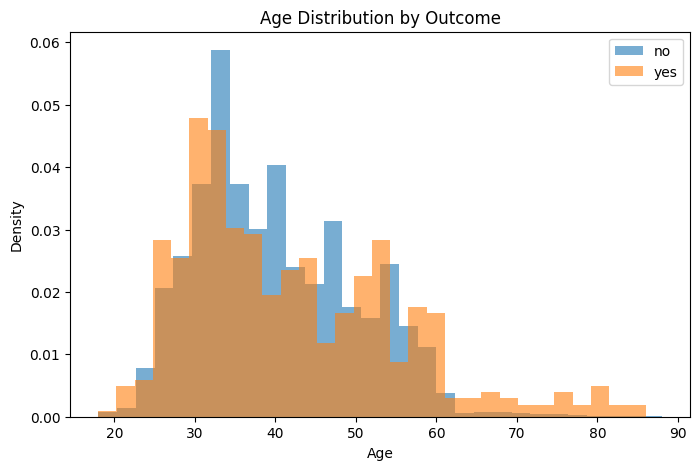

In [11]:
#Histogram comparing age distribution for customers who subscribed vs. those who did not
#Age can influence subscription likelihood, with certain age groups potentially more inclined to subscribe.
plt.figure(figsize=(8,5))

plt.hist(df[df["y"] == "no"]["age"],
         bins=30, alpha=0.6, label="no", density=True)

plt.hist(df[df["y"] == "yes"]["age"],
         bins=30, alpha=0.6, label="yes", density=True)

plt.title("Age Distribution by Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

### Categorical Variable Distributions

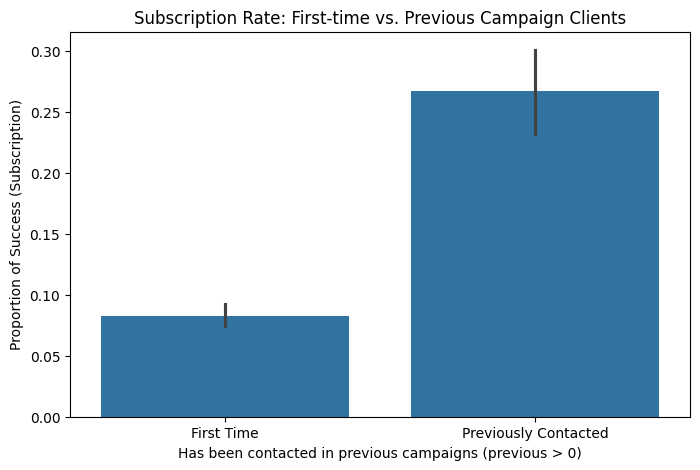

In [12]:
#Barplot comparing subscription rates for clients with and without previous campaign contacts
#Clients who have been contacted in previous campaigns may have a higher subscription rate due to increased familiarity with the bank's offerings, while first-time contacts may have a lower subscription rate.

df['y_numeric'] = df['y'].map({'yes': 1, 'no': 0})
df['has_previous'] = df['previous'] > 0

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='has_previous', y='y_numeric')

plt.title('Subscription Rate: First-time vs. Previous Campaign Clients')
plt.ylabel('Proportion of Success (Subscription)')
plt.xlabel('Has been contacted in previous campaigns (previous > 0)')
plt.xticks([0, 1], ['First Time', 'Previously Contacted'])
plt.show()

# Clean up the temporary column after plotting
df.drop(columns=['y_numeric', 'has_previous'], inplace=True)

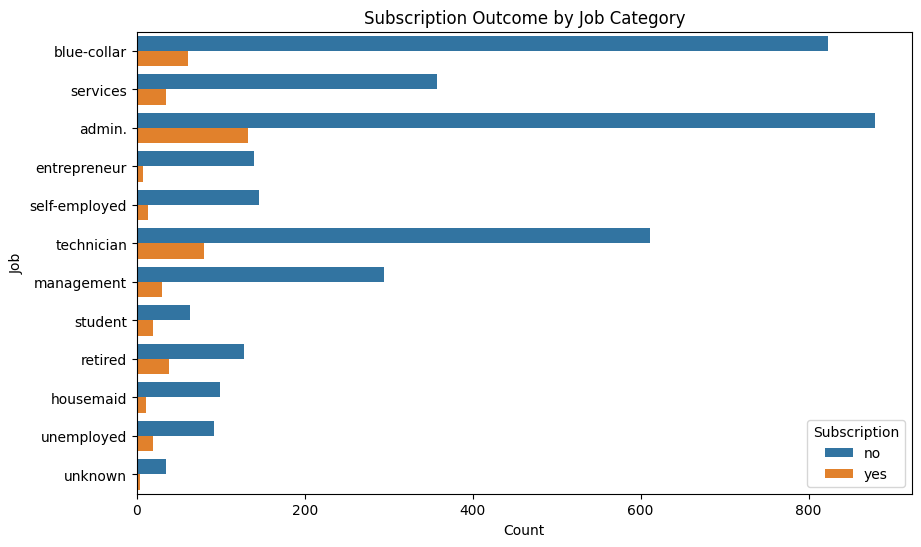

In [13]:
#Barplot comparing subscription rates across different job categories
#Certain job categories may have higher subscription rates due to factors like income stability, financial literacy, or lifestyle, which can influence their likelihood to subscribe to a term deposit.

plt.figure(figsize=(10,6))

sns.countplot(data=df, y='job', hue='y')

plt.title("Subscription Outcome by Job Category")
plt.xlabel("Count")
plt.ylabel("Job")
plt.legend(title="Subscription")
plt.show()

## Special Consideration Variables

One variable that needs special consideration is "duration". It is not available at prediction time and must be discarded from the feature set to avoid data leakage.

Another variable that needs special consideration is "pdays", 96.1% of rows have the value set as "999", meaning the customers have not been previously contacted before or the data has not been saved and is unknown. Instead of treating this variable as continuous it should be converted into a categorical variable of was previously contacted (similarly to "previous")

Finally we have to consider the variable "default", 19.5% of results have implicit missing values. very few clients will admit to being in default, therefore causing the variable to have near zero variance. This could be a potential variable to exclude from the feature set as well.


# Task 3: Task Ordering

## Pipeline and Justification

Task 1: Identifying the Prediction Target

Defines what we are predicting. We need to know what the target of our model is going to be. Every decision, feature, leakage and idea depends on knowing our target variable. No data is transformed, only understand what we are looking for. We ensure this so that we don't mistake the target with a feature.

Task 2: Data Loading and Exploration

Purely observational. No parameters are learned and no rows are modified. We need to understand our data, analyse what it contains and means. This must be task 2 so that we are informed on the data before making decisions about variables, features, encoding or scaling.

Task 3: Task Ordering

Although this isn't a direct task for the machine learning assignment i still believe that this is the right moment to do it.

Once the data is understood, the correct sequence can be justified and documented. Now we know enough about the data to justify each step. This will also help us plan out the project so we can do one step at a time.

Task 4: Data Splitting

This step has to be completed early so leakage is avoided in imputation, scaling and feature selection. The train/validation/test boundary must be established before any fitting transformation so that the validation and test sets are never seen by any fitted component (avoid leakage). Stratification on "y" is applied here to preserve the class distribution across all splits.

Task 5: Managing Missing Values

We need to decide what to do about the missing values before continuing. Imputation strategies need to be fitted on the training set and then applied to the validation and test sets. If done before splitting, test-set missingness patterns would influence the imputed values and training transformations, leaking distributional information.


Task 6: Encoding Categorical Variables

Encoding requires a clean representation, hence why it must be performed after mananaging the missing values so that "unknown" categories are resolved before the encoder is fitted. In addition encodes need to be fitted on the training set only to learn the vocabulary of categories. If the fitting is on the full dataset it would expose the encoder causing it to learn about categories in the validation and test data, leading to structural leakage. 


Task 7: Feature Scaling

Scalers are also fitted on the training set only to learn mean and standard deviation. They need to go after encoding so that all features are numeric. If fitted on the full dataset, the scaler would incorporate the mean and variance of validation/test rows, leaking global distribution statistics into the training normalisation. If done before it would affect the optimization of the logistic regression.

Task 8. Feature Selection

Variance thresholds and correlation analysis are computed on the training set only. They follow scaling so that all features are on comparable scales when computing correlations. "duration" is removed here on conceptual grounds (leakage risk and outcome being known after the result of duration). If feature selection were performed on the full dataset before splitting, retained features would be chosen with knowledge of validation/test variance and correlation structure.

Task 9: Addressing Class Imbalance

Resampling is again applied only to the training set, after all preprocessing is complete. Resampling generates synthetic samples in the transformed feature space, so it must occur after encoding and scaling. This is also so that selected features are consisten between real and synthetic examples. Validation and test sets are never resampled, they must preserve the original class distribution to produce realistic evaluation metrics.

Task 10: Training a Logistic Regression Model 

All preprocessing is finalised. Feature space is defined, transoformations are fitted and class imabalance has been handled. The model is fitted on the (resampled) training set and evaluated on the untouched validation data. This order guarantees that evaluation metrics reflect genuine generalisation.

## Pipeline explanations

|  #  | Task | Allowed Information | Must not use | Data Leakage if unordered |
|-----|----------|----------|----------|----------|
|  1  |Identifying the Prediction Target|Full dataset (read-only) and business objectives          |  -        | -         |
|  2  |Data Loading and Exploration|Full dataset (read-only)          |  -        |    -      |
|  3  |Task Ordering|Observations from task 2          | Any transformations to the data         |     -     |
|  4  |Data Splitting|Full dataset + target distribution          |   No fitted parameters as well as specific feature values to determine the split|  Could lead to preprocessing leakage as the following steps will use future information in the training set        |
|  5  |Managing Missing Values|    Training set statistics      |    Values from the validation and test sets      |    Can lead to preprocessing leakage by incorporating holdout data into the imputation logic. Can lead to over optimistic performance estimates as you directly leak distributional data from the validation and test sets      |
|  6  |Encoding Categorical Variables|      Categories in the training set    |    Unique categories that only appear in the validation or test sets      |    Can lead to label leakage if the encoding uses target information. Model can also gain indirect knowledge of the holdout data meaning preporcessing leakage      |
|  7  |Feature Scaling|    Distributional statistics of the training set      |     Statistics of the full set     |    Scaling the training data using statistics from the test set contaminates the training process, leading to preprocessing leakage      |
|  8  |Feature Selection|    Training set only      |   Global statistics from the whole dataset       |  Selected features might be optimized for the whole dataset. Performance can become over optimistic.        |
|  9  |Addressing Class Imbalance|     Training set     |     Data from the validation and test sets     |  Resampling before splitting can cause synthetic samples to appear in both training and test sets, causing group leakage. This will also lead to overfitting        |
|  10 |Training a Logistic Regression Model|   Training set, features and targets      | Valdiation set labels  and test set       |   Using the validation set for training would cause leakage and end with an overfitted model       |

## Incorrect Ordering and Consequences

One example of incorrect ordering would be if you perform oversampling (SMOTE) on the entire dataset before splitting it into different parts. The algorithm would generate synthetic examples based on the whole population causing data leakage. When you split the data set later on very similar examples will appear in both the training and test sets. 

The model could achieve high precision, recall and accuracy because it recognizes the examples it saw during training. It would fail if it was shown unseen data as it has learned based on specific instances.

# Task 4: Data Splitting


## Split Proportions and Explanation

In [14]:
#Separating the features and target variable
x = df.drop(columns=["y"])
y = df["y"]

#Split the data into training and temp (which will be later split into val and test)
X_train, X_temp, y_train, y_temp = train_test_split(
    x, y,
    test_size=0.30,
    random_state=450,
    stratify=y
)

#Split the temp data into validation and test sets (50% each of the temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=450,
    stratify=y_temp
)

#Verify the split
print("Split summary")
print("=" * 52)
for name, y_split in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    total    = len(y_split)
    yes_n    = (y_split == "yes").sum()
    no_n     = (y_split == "no").sum()
    yes_pct  = yes_n / total * 100
    no_pct   = no_n  / total * 100
    print(f"\n{name} ({total:,} rows)")
    print(f"  no  : {no_n:>4}  ({no_pct:.1f}%)")
    print(f"  yes : {yes_n:>4}  ({yes_pct:.1f}%)")

Split summary

Train (2,883 rows)
  no  : 2567  (89.0%)
  yes :  316  (11.0%)

Validation (618 rows)
  no  :  551  (89.2%)
  yes :   67  (10.8%)

Test (618 rows)
  no  :  550  (89.0%)
  yes :   68  (11.0%)


The dataset is going to be split into three sets using 70% for training, and 15% for both validation and test sets.

Since we only have 4119 observations and approximately 10.9% of those are positive (451), by allocating 70% of the data to training we allow the model to observe enough examples (the minority are positive) to learn a decision boundary. The model has enough examples to know the pattern and generalize. 

The remaining 30% is split between the validation and test sets (15% each). This gives us enough examples to compute metrics such as precision and recall reliably.  Validation will be used during preprocessing and model tuning, whislt test set isn't used until the very end for a final report on the model. 

## Stratification for target variable

The target variable "y" is very imbalanced and with only 451 positive cases in the dataset a fully random split could produce a validation or test set have too many positive/negative cases hence losing the proportion that we have in the dataset. Stratified splitting will force each split to maintain the 89.1% : 10.9% ratio.

This ensures that the model trains on a minority class distribution and validation metrics are computed against a realisitc ratio. Results will also be reproducible and comparable each run.

## Pipeline splitting stage

The split has to be performed right after the exploration and task ordering, and before any fitting transformation (processing) is applied.

If it was performed later on the following types of leakage could occur:

Preprocessing Leakage: By calculating distributional statistics on the full dataset, future information is included in the model training data. The model will see the spread and range of the test set before it is evaluated.

Target leakage: If feature selection is performed before the split features might be selected because they correlate with targets in the validation or test sets.

Splitting later in the pipeline would cause information from the validation or test sets to be implicitly encoded into the transformations producing biased evaluation metrics and inflated performance results. The model will appear to work on the test set but when tested with real unseen data it will likely fail.

# Task 5: Managing Missing Values

## Explicit vs Implicit missing values

In [15]:
#Create a copy of datasets to avoid modifying the original dataframes
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

print("Implicit missing values in training set")
print("=" * 50)

#Check for 'unknown' values in categorical columns and their relationship with the target variable
cat_cols = ["job", "marital", "education", "default", "housing", "loan"]
for col in cat_cols:
    n = (X_train[col] == "unknown").sum()
    pct = n / len(X_train) * 100
    sub_unk = y_train[X_train[col] == "unknown"].eq("yes").mean()
    sub_kno = y_train[X_train[col] != "unknown"].eq("yes").mean()
    print(f"  {col:<12} unknown={n:>3} ({pct:.1f}%)  "
          f"sub_rate_unknown={sub_unk:.3f}  sub_rate_known={sub_kno:.3f}")

#Check for '999' values in numerical columns and their relationship with the target variable
pdays_sentinel = (X_train["pdays"] == 999).sum()
print(f"\n  pdays==999: {pdays_sentinel} ({pdays_sentinel/len(X_train)*100:.1f}%) "
      f"— sentinel for 'never previously contacted'")

Implicit missing values in training set
  job          unknown= 31 (1.1%)  sub_rate_unknown=0.097  sub_rate_known=0.110
  marital      unknown=  8 (0.3%)  sub_rate_unknown=0.000  sub_rate_known=0.110
  education    unknown=124 (4.3%)  sub_rate_unknown=0.161  sub_rate_known=0.107
  default      unknown=545 (18.9%)  sub_rate_unknown=0.064  sub_rate_known=0.120
  housing      unknown= 73 (2.5%)  sub_rate_unknown=0.110  sub_rate_known=0.110
  loan         unknown= 73 (2.5%)  sub_rate_unknown=0.110  sub_rate_known=0.110

  pdays==999: 2782 (96.5%) — sentinel for 'never previously contacted'


### Summary

All of these results are based on the training set

Explicit: There are no explicit values in the dataset. 

Implicit: 

**Unknown Category**

| Column      | Unknown (train) | % of train | Subscription rate (unknown) | Subscription rate (known) | Strategy |
|-------------|----------------|------------|----------------------------|--------------------------| ---------- |
| "job"  | 31    | 1.1%    | 9.7%                    | 11.0%              |      Mode Imputation      |
| "marital" | 8     | 0.03%    | 0.0%                      | 11.0%                    |   Mode Imputation      |
| "education"   | 124     | 4.3%      | 16.1%                       | 10.7%                    |    Retain as category      |
| "default" | 545    | 18.9%   | 6.4%               | 12.0%     |     Retain as category    |
| "housing"   | 73      | 2.5%     | 11.0%                       | 11.0%                    |  Mode Imputation     |
| "loan"   | 73     | 2.5%      | 11.0%                      | 11.0%                    |   Mode Imputation   |


**999**

Sentinel value "999" in "pdays" is a numerical implicit missing value. "pdays" records the number of days since a client was last contacted in a previous campaign. The value "999" encodes "never previously contacted" — and is not a real measurement. It appears in 96.5% of training rows, making "pdays" effectively a near-binary variable rather than a continuous one. (Either they have been contacted or not)



## Strategy and Justification

### Code

In [16]:
#Impute 'unknown' with mode for job, marital, housing, loan
impute_cols = ["job", "marital", "housing", "loan"]
modes = {col: X_train[col].replace("unknown", pd.NA).mode()[0]
         for col in impute_cols}

print("\nMode imputation values (fitted on training set only):")
for col, val in modes.items():
    print(f"  {col:<10} → '{val}'")

for split in [X_train, X_val, X_test]:
    for col, mode_val in modes.items():
        split[col] = split[col].replace("unknown", mode_val)


Mode imputation values (fitted on training set only):
  job        → 'admin.'
  marital    → 'married'
  housing    → 'yes'
  loan       → 'no'


In [17]:
# No transformation needed, 'unknown' is kept as a valid level.
print("\n'default' and 'education': retaining 'unknown' as separate category.")
print(f"default unique values: {sorted(X_train['default'].unique())}")
print(f"education unique values: {sorted(X_train['education'].unique())}")


'default' and 'education': retaining 'unknown' as separate category.
default unique values: ['no', 'unknown', 'yes']
education unique values: ['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown']


In [18]:
#Split the variable into two new variables and drop the original "pdays"
for split in [X_train, X_val, X_test]:
    split["previously_contacted"] = (split["pdays"] != 999).astype(int)
    split["pdays_clean"] = split["pdays"].replace(999, 0)
    split.drop(columns=["pdays"], inplace=True)

# Verify the new features
print("\npdays engineering complete:")
print(f"previously_contacted — train: "
      f"{X_train['previously_contacted'].value_counts().to_dict()}")
print(f"pdays_clean — train non-zero: "
      f"{(X_train['pdays_clean'] > 0).sum()} rows")


pdays engineering complete:
previously_contacted — train: {0: 2782, 1: 101}
pdays_clean — train non-zero: 100 rows


In [ ]:
#Verify if the code worked
cat_cols = ["job", "marital", "education", "default", "housing", "loan"]
for col in cat_cols:
    n = (X_train[col] == "unknown").sum()
    pct = n / len(X_train) * 100
    sub_unk = y_train[X_train[col] == "unknown"].eq("yes").mean()
    sub_kno = y_train[X_train[col] != "unknown"].eq("yes").mean()
    print(f"  {col:<12} unknown={n:>3} ({pct:.1f}%)  "
          f"sub_rate_unknown={sub_unk:.3f}  sub_rate_known={sub_kno:.3f}")

  job          unknown=  0 (0.0%)  sub_rate_unknown=nan  sub_rate_known=0.110
  marital      unknown=  0 (0.0%)  sub_rate_unknown=nan  sub_rate_known=0.110
  education    unknown=124 (4.3%)  sub_rate_unknown=0.161  sub_rate_known=0.107
  default      unknown=545 (18.9%)  sub_rate_unknown=0.064  sub_rate_known=0.120
  housing      unknown=  0 (0.0%)  sub_rate_unknown=nan  sub_rate_known=0.110
  loan         unknown=  0 (0.0%)  sub_rate_unknown=nan  sub_rate_known=0.110


### Strategy per variable

"job" - Mode Imputation (Data cleaning)

There are only 31 instances of this variable being unknown and the subscription rate of the unknown category is close enough to the known rate of 11% that the difference is unlikely to be meaningful at this sample size. I will carry out mode imputation using the trainign set and apply it across the validation and test sets.

"marital" - Mode Imputation (Data cleaning)

There are only 8 instances of this variable being unknown and the subscription rate of the unknown category is 0.0%. With so few observations this isn't statistically reliable and is more likely due to the sampling and splitting (chance). Keeping the separate category could provide unreliable results and destabalize the encoder. I will carry out mode imputation using the trainign set and apply it across the validation and test sets.

"education" - Retain as category (Modeling decision)

There are 124 unknown istances of this variable and the unknown subscription rate is 16.1% compared to the 10.7% of known. The clients that didn't discolse their education aren't a random part of the population, they belong in a different group. Being part of this unknown category has a higher subscription rate than the known category. 

Using mode imputation would missrepresent the 124 people who belong to a different group. Therefore we will retain "unknown" as a separate class for the model

"default" - Retain as category (Modeling decision)

There are 545 unknown instances (18.9% of total) of this variable and the unknown subscription rate is 6.4% compared to the known rate of 12.0%. This indicates that clients who decline to disclose their default status behave differently to those that do (lower subscription rate). 

Mode imputation would assing "no" to all these people and the signal would be lost, hence we are keeping the "unknown" category 

"housing" - Mode Imputation (Data cleaning)

There are 73 instances of this variable being unknown and the subscription rates for both unknown and unknown are the same, sitting at 11.0%. There is no evidence that the unknown category is carrying any predictive value. I will carry out mode imputation using the trainign set and apply it across the validation and test sets.

"loan" - Mode Imputation (Data cleaning)

There are 73 instances of this variable being unknown and the subscription rates for both unknown and unknown are the same, sitting at 11.0%. There is no evidence that the unknown category is carrying any predictive value. I will carry out mode imputation using the trainign set and apply it across the validation and test sets.

"pdays"

Since 96.5% of "pdays" values are the sentinel value "999" (extremely skewed), the column cannot be treated as a continuous variable. Passing it directly to a scaler would produce a heavily distorted normalisation dominated by a non-informative code. Two features are derived instead:

"previously_contacted":

Binary indicator: "1" if "pdays" != "999", else "0". 
Captures whether the client has any prior campaign history at all.

"pdays_clean": 

The actual number of days for clients who were previously contacted, set to "0" for all others. This preserves the recency signal for the 3.5% of clients with a actual prior contact.

The original "pdays" column is then dropped. This transformation is rule-based — no parameters are learned from data — and is therefore applied identically to all splits without any risk of leakage. Keeping the column would cause multicollinearity between the new features and would distort scaling.

## Operations on missing variables

| Operation | Parameter learned | Leakage if fitted on full dataset |
|-----------|------------------|----------------------------------|
| Mode imputation ("job", "marital", "housing", "loan") | Mode value per column | Global mode absorbs val/test distribution; imputed values reflect unseen data |
| "unknown" category retention ("default", "education") | None | No leakage risk |
| "pdays" feature engineering | None| No leakage risk |

Only mode imputation requires a fitted parameter on the training set. All other operations in this task are deterministic transformations that are safe to apply uniformly across all splits.

## Data Cleaning vs Modeling decisions

The strategy for each variable is decided by considering the following: Does the fact that a value is missing carry predictive information in itself?

If it does, missingness should be preserved. If not, it is a structural gap that should be filled to avoid introducing sparse, uninformative categories into the model.

Data cleaning decisions:

Correct structural gaps where missingness is random and the unknown group behaves indistinguishably from the known population (it has no effect on the target variable). Mode imputation is the best option here.

Modelling decisions:

Arise when the unknown group has a meaningfully different subscription rate — the missingness is has an effect on the outcome and should be preserved as its own category rather than collapsed into the majority class.

# Task 6